# MNIST-Planted-Cov: backbone pretraining and run analysis

Two jobs in one notebook, both for the planted-covariance design in
`datasets/MNIST_add_cov_dataset_planted.py` (`+data=mnist_planted_cov`):

```
input      five MNIST digits stacked as channels           [5, 28, 28]
concepts   A = 1[d1>=5]  B = 1[d2>=5]  D1 = 1[d3>=5]  D2 = 1[d4>=5]     supervised
hidden     X = 1[d5>=5]                                                never supervised
target     y = 4A + 2B + X                                             8 classes
planted    P(X=1 | A,B) = 0.5 + kappa/2 (A + B - 1)   ->  corr(A,X) = corr(B,X) = kappa/2
           corr(D1,X) = corr(D2,X) = 0 by construction
```

**Part 1** trains the per-channel digit encoder on *exactly* this input: 5 channels, the
noise on channel 5 that the SCBM run will see, the same split seed. That removes the two
mismatches of the carry backbone (4 channels, clean digits). The result is a state dict for
`model.pretrained_encoder_path`.

**Part 2** reads a finished run's dumps (`<run>/test/*.pt` + `model_best.pth`) and answers,
in order: did the residual pick up X, and does the concept-residual correlation point at
A and B rather than D1 and D2? Everything in Part 2 is self-contained: X is recovered from
the dumps as `y_true - 4A - 2B`, so no dataset rebuild is needed for the analysis.

Guardrail: probes and correlations say what is *recoverable* from the residual and which
concepts it *co-varies* with. They do not say the residual "is" X.

## 0. Setup

In [142]:
import os, sys, json, socket, time
from pathlib import Path

REPO_DEFAULT = Path("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation")

def find_repo_root(start=None):
    marker = Path("datasets") / "MNIST_add_cov_dataset_planted.py"
    for c in [Path(start or Path.cwd()).resolve(), *Path(start or Path.cwd()).resolve().parents]:
        if (c / marker).is_file():
            return c
    return REPO_DEFAULT

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from datasets.MNIST_add_cov_dataset_planted import (
    get_MNIST_add_cov_datasets, summarize_dataset, CONCEPT_NAMES,
)
from models.models import PerChannelMNISTEncoder
from utils.utils import reset_random_seeds

ON_CLUSTER = "biomed" in socket.gethostname()
DATA_PATH = "/cluster/home/smarcou/work/Data/" if ON_CLUSTER else "datasets/"
EXPERIMENTS = Path("/cluster/home/smarcou/work/experiments_scbm") if ON_CLUSTER else REPO_ROOT / "experiments"
BACKBONE_ROOT = Path("/cluster/home/smarcou/work/backbones") if ON_CLUSTER else REPO_ROOT / "experiments" / "backbones"

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"repo {REPO_ROOT}\ndata {DATA_PATH}\ndevice {device}")

repo /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation
data datasets/
device mps


### The run these settings describe

Everything below is keyed on this one block. The backbone is trained on the same split the
SCBM run trains on (`data_seed`), with the same corruption on the same channel, so the
encoder never sees an input distribution the run will not show it.

In [143]:
EXPERIMENT   = "planted_parents"   # planted_parents | planted_swap | planted_diff
KAPPA        = 0.6                 # corr(parent, X) = KAPPA / 2
CORR_TYPE_X  = "mask"              # corruption on channel 5 (X's digit): gaussian | blur | occlusion | mask
CORR_TYPE_C  = "mask"              # corruption on channels 1-4
CORR_X       = 0.5                 # strength; for "mask" the probability the channel is blanked. 0.0 -> clean
CORR_C       = 0.3                 # X and a parent are jointly masked at CORR_X * CORR_C per parent
DATA_SEED    = 0                   # split seed; pass the same as data.data_seed to train.py
NUM_CHANNELS = 5

# Backbone training budget. The capacity notebook used the model config's 300 epochs /
# patience 75; a digit reader converges far sooner, so these are capped here.
BB_EPOCHS      = 60
BB_PATIENCE    = 10
BB_MIN_EPOCHS  = 20
BB_LR          = 1e-4
BB_BATCH       = 64

# True: train the backbone in Part 1 and save it. False: load BACKBONE_DIR/encoder.pt,
# freeze it, fit fresh linear digit heads on top (the saved file holds only the encoder),
# and run the test-accuracy cell against that. The save cell is skipped either way when
# False. Part 2 needs neither.
TRAIN_BACKBONE = True
HEAD_EPOCHS    = 3      # linear-probe budget for the fresh heads when TRAIN_BACKBONE=False
HEAD_LR        = 1e-3

# Gaussian keeps the historical cx/cc naming; other modes spell the mode out.
_corr_tag = (f"cx{CORR_X}_cc{CORR_C}" if CORR_TYPE_X == CORR_TYPE_C == "gaussian"
             else f"{CORR_TYPE_X}x{CORR_X}_{CORR_TYPE_C}c{CORR_C}")
BACKBONE_NAME = f"{EXPERIMENT}_k{KAPPA}_{_corr_tag}_s{DATA_SEED}_perchannel".replace(".", "")
BACKBONE_DIR  = BACKBONE_ROOT / BACKBONE_NAME
print("backbone ->", BACKBONE_DIR / "encoder.pt")

backbone -> /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/backbones/planted_parents_k06_maskx05_maskc03_s0_perchannel/encoder.pt


## 1. The dataset, built the way `train.py` builds it

In [144]:
config_data = OmegaConf.merge(
    OmegaConf.load("configs/data/data_defaults.yaml"),
    OmegaConf.load("configs/data/mnist_planted_cov.yaml"),
)
OmegaConf.set_struct(config_data, False)
config_data.data_path = DATA_PATH
config_data.experiment = EXPERIMENT
config_data.kappa = KAPPA
config_data.num_covariates = NUM_CHANNELS
config_data.corruption = CORR_TYPE_X
config_data.corruption_strength = CORR_X
config_data.concept_corruption = CORR_TYPE_C
config_data.concept_corruption_strength = CORR_C
config_data.data_seed = DATA_SEED

# utils/data.py passes data_seed when set, else the run seed. Same here.
split_seed = DATA_SEED if DATA_SEED is not None else 0
gen = reset_random_seeds(split_seed)
torch.use_deterministic_algorithms(False)   # conv backward has no deterministic CUDA kernel

trainset, valset, testset = get_MNIST_add_cov_datasets(config_data, seed=split_seed)
print(len(trainset), len(valset), len(testset))
summarize_dataset(trainset)

ValueError: Unknown corruption='mask'. Use 'none', 'gaussian', 'blur' or 'occlusion'.

### Design check

Empirical correlations on the split against the planted values. If A and B are not at
kappa/2 and D1, D2 not at zero, nothing downstream is interpretable.

In [ ]:
def design_table(ds, kappa):
    obs = ds.observed_concepts; x = ds.hidden_concepts[:, 1]; y = ds.task_labels
    rows = []
    for j, name in enumerate(["A", "B", "D1", "D2"]):
        r = np.corrcoef(obs[:, j], x)[0, 1]
        rows.append((name, r))
    code_ = obs @ (2 ** np.arange(4)); hit = 0
    for k in np.unique(code_):
        m = code_ == k; hit += np.bincount(y[m].astype(int)).max()
    ceiling = hit / len(y)
    return rows, ceiling

rows, CEILING = design_table(trainset, KAPPA)
print(f"{'concept':>8} {'corr(c,X)':>10}   planted")
for name, r in rows:
    planted = KAPPA / 2 if name in ("A", "B") else 0.0
    if EXPERIMENT == "planted_swap": planted = KAPPA / 2 if name in ("D1", "D2") else 0.0
    if EXPERIMENT == "planted_diff": planted = {"A": KAPPA/2, "B": -KAPPA/2}.get(name, 0.0)
    print(f"{name:>8} {r:>+10.3f}   {planted:+.3f}")
print(f"\nconcept-only task ceiling (train): {CEILING:.4f}   designed {0.5 + KAPPA/4:.4f}")
print(f"residual headroom                : {1 - CEILING:.4f}")

 concept  corr(c,X)   planted
       A     +0.299   +0.300
       B     +0.313   +0.300
      D1     +0.019   +0.000
      D2     +0.013   +0.000

concept-only task ceiling (train): 0.6584   designed 0.6500
residual headroom                : 0.3416


In [ ]:
# A few samples: channels 1-4 clean, channel 5 noisy.
fig, axes = plt.subplots(3, NUM_CHANNELS, figsize=(2.0 * NUM_CHANNELS, 6))
for i in range(3):
    s = trainset[i]
    for c in range(NUM_CHANNELS):
        axes[i, c].imshow(s["features"][c], cmap="gray", vmin=0, vmax=1)
        axes[i, c].set_title(f"d{c+1}={int(s['digit_labels'][c])}", fontsize=9)
        axes[i, c].axis("off")
    axes[i, 0].set_ylabel(f"y={int(s['labels'])} X={int(s['X'])}")
plt.suptitle(f"channels 1-4: concept digits ({CORR_TYPE_C} {CORR_C}), channel 5: X's digit ({CORR_TYPE_X} {CORR_X})")
plt.tight_layout(); plt.show()

## 2. Backbone: the per-channel digit encoder on this exact input

Same recipe as the capacity notebook's section 10b, with two changes that are the point of
doing it here: the encoder is the class from `models/models.py` (not a notebook copy, so the
state dict matches what `train.py` builds), and the input is the planted 5-channel stack
with channel 5 corrupted.

One 10-way digit head per channel, summed cross-entropy, Adam, early stopping on the mean
validation digit accuracy. The heads are thrown away; only `encoder.state_dict()` is saved. Under `mask` corruption a
blanked channel has no digit to predict, so each channel's cross-entropy and accuracy are
taken over the samples where that channel is visible (`channel_mask` from the dataset).
The shared `digit_net` therefore has to read clean digits *and* the noisy fifth digit with
the same weights, which is what the SCBM run will demand of it.

In [ ]:
class BackboneFrom(nn.Module):
    """Encoder + one 10-way head per channel. The heads exist only for pretraining."""
    def __init__(self, encoder, n_heads, feat_dim):
        super().__init__()
        self.encoder = encoder
        self.heads = nn.ModuleList([nn.Linear(feat_dim, 10) for _ in range(n_heads)])
    def forward(self, x):
        h = self.encoder(x)
        return h, [head(h) for head in self.heads]


def _visible(batch):
    """[B, n_channels] bool: channels that were NOT blanked (all True without mask corruption)."""
    return ~batch["channel_mask"].to(device)


@torch.no_grad()
def digit_acc_all(model, loader, return_masked_frac=False):
    """Per-channel digit accuracy over the samples where that channel is visible."""
    model.eval(); hits = None; seen = None; n = 0
    for batch in loader:
        _, logits = model(batch["features"].to(device))
        d = batch["digit_labels"].to(device); vis = _visible(batch)
        h = torch.stack([((lg.argmax(1) == d[:, k]) & vis[:, k]).sum() for k, lg in enumerate(logits)])
        s = vis.sum(0)
        hits = h if hits is None else hits + h; seen = s if seen is None else seen + s; n += d.size(0)
    acc = (hits.float() / seen.clamp_min(1).float()).cpu().tolist()
    return (acc, (1 - seen.float() / n).cpu().tolist()) if return_masked_frac else acc


def masked_digit_loss(logits, d, vis, ce):
    """Summed per-channel CE, each channel averaged over its visible samples only:
    a blanked channel has no digit to predict, so it contributes no loss."""
    total = 0.0
    for k, lg in enumerate(logits):
        m = vis[:, k]
        if m.any():
            total = total + ce(lg[m], d[m, k])
    return total


def pretrain_digits(model, loaders, epochs, patience, min_epochs, lr):
    opt = optim.Adam(model.parameters(), lr=lr)
    ce = nn.CrossEntropyLoss()
    best = {"val": -1.0, "epoch": -1, "state": None}; stale = 0
    hdr = "  ".join(f"d{k+1}" for k in range(NUM_CHANNELS))
    print(f"{'ep':>4} {'loss':>8} {'val mean':>9}   {hdr}")
    for epoch in range(epochs):
        model.train(); running = seen = 0
        for batch in loaders["train"]:
            x = batch["features"].to(device); d = batch["digit_labels"].to(device)
            _, logits = model(x)
            loss = masked_digit_loss(logits, d, _visible(batch), ce)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        accs = digit_acc_all(model, loaders["val"]); vm = float(np.mean(accs))
        print(f"{epoch:>4} {running/seen:>8.4f} {vm:>9.4f}   " + "  ".join(f"{a:.3f}" for a in accs))
        if vm > best["val"]:
            best = {"val": vm, "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
            stale = 0
        else:
            stale += 1
        if epoch + 1 >= min_epochs and stale >= patience:
            print(f"early stop; best val {best['val']:.4f} @ epoch {best['epoch']}"); break
    model.load_state_dict(best["state"])
    return best

In [ ]:
bb_loaders = {
    "train": DataLoader(trainset, batch_size=BB_BATCH, shuffle=True, num_workers=0,
                        generator=gen, drop_last=True),
    "val":   DataLoader(valset, batch_size=256, shuffle=False, num_workers=0),
    "test":  DataLoader(testset, batch_size=256, shuffle=False, num_workers=0),
}

reset_random_seeds(split_seed)
torch.use_deterministic_algorithms(False)

feat_dim = PerChannelMNISTEncoder.FEATURES_PER_DIGIT * NUM_CHANNELS      # 32 per digit -> 160
encoder = PerChannelMNISTEncoder(in_channels=NUM_CHANNELS, output_dim=feat_dim)
backbone = BackboneFrom(encoder, n_heads=NUM_CHANNELS, feat_dim=feat_dim).to(device)
print(f"{sum(p.numel() for p in backbone.parameters()):,} params, feature dim {feat_dim}")

if TRAIN_BACKBONE:
    t0 = time.time()
    bb_best = pretrain_digits(backbone, bb_loaders, BB_EPOCHS, BB_PATIENCE, BB_MIN_EPOCHS, BB_LR)
    print(f"trained in {(time.time() - t0)/60:.1f} min")
else:
    # Encoder training is off: load the saved weights and freeze them. Only
    # encoder.state_dict() was saved, so the 10-way heads are re-fitted as a linear
    # probe on frozen features. Their test accuracy then measures the *saved encoder*
    # (is digit identity linearly readable per channel), not the probe.
    enc_path = BACKBONE_DIR / "encoder.pt"
    print("TRAIN_BACKBONE=False: loading", enc_path)
    backbone.encoder.load_state_dict(torch.load(enc_path, map_location=device))   # strict
    meta_path = BACKBONE_DIR / "meta.json"
    print(meta_path.read_text() if meta_path.exists() else "(no meta.json next to it)")

    backbone.encoder.eval()
    for p in backbone.encoder.parameters():
        p.requires_grad_(False)

    opt = optim.Adam(backbone.heads.parameters(), lr=HEAD_LR)
    ce = nn.CrossEntropyLoss()
    t0 = time.time()
    for epoch in range(HEAD_EPOCHS):
        backbone.heads.train(); running = seen = 0
        for batch in bb_loaders["train"]:
            x = batch["features"].to(device); d = batch["digit_labels"].to(device)
            with torch.no_grad():
                h = backbone.encoder(x)
            loss = masked_digit_loss([head(h) for head in backbone.heads], d, _visible(batch), ce)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        accs = digit_acc_all(backbone, bb_loaders["val"])
        print(f"probe ep {epoch} loss {running/seen:.4f} val mean {np.mean(accs):.4f}   "
              + "  ".join(f"{a:.3f}" for a in accs))
    print(f"heads fitted on frozen encoder in {(time.time() - t0)/60:.1f} min")
    assert all(not p.requires_grad for p in backbone.encoder.parameters())


### Test accuracy per digit

Channels 1-4 should sit near 0.98, matching the carry backbone. Channel 5 is the one to
read: it is what the residual will have to work with, and the raw-pixel ceiling for X at
corruption 0.4 was about 0.96 in the dataset notebook.

With `TRAIN_BACKBONE=False` these numbers come from the *saved* encoder under fresh linear
heads, so they should reproduce `meta.json`'s `test_digit_acc` up to probe noise. A gap
means the file on disk is not the encoder the metadata describes.


In [ ]:
src = "trained here" if TRAIN_BACKBONE else f"saved encoder {BACKBONE_DIR.name} + fresh linear heads"
print("evaluating:", src)
bb_test, bb_masked = digit_acc_all(backbone, bb_loaders["test"], return_masked_frac=True)
for k, (a, mf) in enumerate(zip(bb_test, bb_masked)):
    role = ["A", "B", "D1", "D2", "X (corrupted)"][k] if k < 5 else "padding"
    print(f"d{k+1}  {role:<14} test digit acc {a:.4f}   (on visible samples; masked fraction {mf:.3f})")

# X itself, read as 1[argmax >= 5] off the channel-5 head: the ceiling a residual can reach.
@torch.no_grad()
def x_from_channel5(model, loader):
    model.eval(); hit = n = 0
    for batch in loader:
        _, logits = model(batch["features"].to(device))
        vis = _visible(batch)[:, 4]
        pred_x = (logits[4].argmax(1) >= 5).long()
        hit += ((pred_x == batch["X"].to(device).long()) & vis).sum().item(); n += vis.sum().item()
    return hit / max(n, 1)
print(f"\nX from channel 5 (argmax>=5), visible samples only: {x_from_channel5(backbone, bb_loaders['test']):.4f}")
print("On a masked sample channel 5 carries nothing: the SCBM has to fall back on A and B there, which is the point.")


### Save

Only the encoder's state dict, under a name that records what it was trained on, plus a
`meta.json` so the folder is self-describing. On the cluster this writes straight to
`/cluster/home/smarcou/work/backbones/`; locally it goes to `experiments/backbones/` and
has to be copied over.

In [ ]:
if TRAIN_BACKBONE:
    BACKBONE_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(backbone.encoder.state_dict(), BACKBONE_DIR / "encoder.pt")
    meta = {
        "encoder_arch": "per_channel_mnist_encoder",
        "features_per_digit": PerChannelMNISTEncoder.FEATURES_PER_DIGIT,
        "num_covariates": NUM_CHANNELS,
        "experiment": EXPERIMENT, "kappa": KAPPA,
        "corruption": CORR_TYPE_X, "corruption_strength": CORR_X,
        "concept_corruption": CORR_TYPE_C, "concept_corruption_strength": CORR_C,
        "test_masked_fraction": bb_masked,
        "data_seed": DATA_SEED,
        "trained_on": "10-way digit identity per channel, summed CE",
        "best_val_mean_digit_acc": bb_best["val"], "best_epoch": bb_best["epoch"],
        "test_digit_acc": bb_test,
        "date": time.strftime("%Y-%m-%d %H:%M"),
    }
    (BACKBONE_DIR / "meta.json").write_text(json.dumps(meta, indent=2))
    print("saved", BACKBONE_DIR / "encoder.pt")
#
    cluster_path = f"/cluster/home/smarcou/work/backbones/{BACKBONE_NAME}/encoder.pt"
    if not ON_CLUSTER:
        print(f"\ncopy to the cluster:\n  scp -r '{BACKBONE_DIR}' biomed:/cluster/home/smarcou/work/backbones/")
    print(f"""
    sbatch train_mnist.sh +model=SCBM_RES +data=mnist_planted_cov \\
      data.experiment={EXPERIMENT} data.kappa={KAPPA} data.data_seed={DATA_SEED} data.num_residuals=5 \\
      data.corruption={CORR_TYPE_X} data.corruption_strength={CORR_X} \\
      data.concept_corruption={CORR_TYPE_C} data.concept_corruption_strength={CORR_C} \\
      model.reg_precision=none model.reg_weight=0 model.weight_decay=1e-4 model.early_stopping_patience=100 \\
      model.encoder_arch=per_channel_mnist_encoder \\
      model.pretrained_encoder_path={cluster_path} model.freeze_encoder=False \\
      seed=0 save_model=True save_name={BACKBONE_NAME.replace('_perchannel','')}_R5_wd1e-4_perchannel_global_reg0
    """)
else:
    print("skipped (TRAIN_BACKBONE=False)")

### Sanity: the saved file loads into the model `train.py` builds

`load_and_maybe_freeze_encoder` calls `load_state_dict` strictly, so a key or shape
mismatch would fail the job at construction. Cheaper to find out here.

In [ ]:
from models.models import SCBM_residual

cfg = OmegaConf.merge(
    OmegaConf.load("configs/config.yaml"),
    {"data": config_data,
     "model": OmegaConf.merge(OmegaConf.load("configs/model/model_defaults.yaml"),
                              OmegaConf.load("configs/model/SCBM_RES.yaml"))},
)
OmegaConf.set_struct(cfg, False)
cfg.model.encoder_arch = "per_channel_mnist_encoder"
cfg.model.pretrained_encoder_path = str(BACKBONE_DIR / "encoder.pt")
cfg.data.num_residuals = 1
m = SCBM_residual(cfg)
with torch.no_grad():
    out = m(trainset[0]["features"].unsqueeze(0), epoch=0, validation=True)
print("forward ok; c_res_mu shape", tuple(out[1].shape))

Loaded pretrained encoder weights from /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/backbones/planted_parents_k06_cx05_cc04_s0_perchannel/encoder.pt
forward ok; c_res_mu shape (1, 5, 5)


---
## 3. Analysis of finished runs

Point `RUNS` at run folders under `experiments/scbm_residual/MNIST-Add-Cov/`. Every run
must have been trained with `data.save_concept_and_residual_channel=True` (the planted
yaml default), which writes `c_res_mu.pt`, `covariance_matrices.pt`, `c_true.pt`,
`y_true.pt`, `y_pred.pt` into `<run>/{train,val,test}/`.

Each entry: a label, the folder name, and the kappa it was trained at (read from `log.txt`
if left `None`).

In [ ]:
RUN_ROOT = EXPERIMENTS / "scbm_residual" / "MNIST-Add-Cov"

RUNS = {
    # "k06_R1_s0": {
    #     "folder": "planted_planted_parents_planted_parents_k06_cx04_cc00_s0_R1_wd1e-4_perchannel_2026-09-15_22-42-35_seed_0_1a329",
    #     "kappa": None,
    # },
    "k06_R5_cx00_global_reg1": {
        "folder": "planted_planted_parents_planted_parents_k06_cx00_cc00_s0_R5_wd1e-4_perchannel_global_reg1_2026-09-16_12-31-28_seed_0_f2cc5",
        "kappa": None,
    },
    "k06_R5_cx00_global_reg0": {
        "folder": "planted_planted_parents_planted_parents_k06_cx00_cc00_s0_R5_wd1e-4_perchannel_global_reg0_2026-09-16_13-10-13_seed_0_e0336",
        "kappa": None,
    },
    # Corrupted concept channels (cc04) + corrupted X channel (cx05), extended L_int at weight 1.
    "k06_R5_cx05_cc04_Lint1": {
        "folder": "planted_planted_parents_planted_parents_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_15-16-51_seed_0_c84e5",
        "kappa": None,
    },
    # Control for the run above: same cc04 / cx05 settings, no L_int (early-stopping patience 10, not 30).
    "k06_R5_cx05_cc04_noLint": {
        "folder": "planted_planted_parents_planted_parents_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_noLint_2026-09-16_16-21-46_seed_0_a3e46",
        "kappa": None,
    },
    # planted_swap: X generated from D1/D2, y still 4A + 2B + X. Same cc04 / cx05 / L_int settings
    # (patience 10). Decides whether the Sigma cross-block follows the parents or the task concepts.
    "k06_R5_cx05_cc04_Lint1_swap": {
        "folder": "planted_planted_swap_planted_swap_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_17-00-03_seed_0_327de",
        "kappa": None,
    },
}
# Convenience: pick up every planted-design run in the folder if RUNS is left empty.
# The old carry runs are also named planted_* (train.py's naming), so the run's own
# config decides, not the folder name.
import ast
if not RUNS:
    for p in sorted(RUN_ROOT.glob("planted_*")):
        if not (p / "test" / "c_res_mu.pt").exists() or not (p / "model_best.pth").exists():
            continue
        with open(p / "log.txt") as f:
            exp = ast.literal_eval(f.readline().strip())["data"].get("experiment", "")
        if str(exp).startswith("planted"):
            RUNS[p.name[:60]] = {"folder": p.name, "kappa": None}
print(len(RUNS), "runs")
for k, v in RUNS.items(): print(" ", v["folder"])

5 runs
  planted_planted_parents_planted_parents_k06_cx00_cc00_s0_R5_wd1e-4_perchannel_global_reg1_2026-09-16_12-31-28_seed_0_f2cc5
  planted_planted_parents_planted_parents_k06_cx00_cc00_s0_R5_wd1e-4_perchannel_global_reg0_2026-09-16_13-10-13_seed_0_e0336
  planted_planted_parents_planted_parents_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_15-16-51_seed_0_c84e5
  planted_planted_parents_planted_parents_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_noLint_2026-09-16_16-21-46_seed_0_a3e46
  planted_planted_swap_planted_swap_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_17-00-03_seed_0_327de


In [ ]:
import ast

CONCEPTS = ["A", "B", "D1", "D2"]

def read_run_config(run_dir):
    with open(run_dir / "log.txt") as f:
        return ast.literal_eval(f.readline().strip())

def load_split(run_dir, split="test"):
    d = run_dir / split
    t = lambda name: torch.load(d / name, map_location="cpu")
    out = {
        "c_res_mu": t("c_res_mu.pt").float().numpy(),
        "sigma":    t("covariance_matrices.pt").float().numpy(),      # Sigma = L L^T per sample
        "c_true":   t("c_true.pt").float().numpy(),
        "y_true":   t("y_true.pt").long().numpy(),
        "y_pred":   t("y_pred.pt").float().numpy(),
        "probs":    t("concepts_residuals_pred_probs_mean.pt").float().numpy(),
    }
    C = out["c_true"].shape[1]
    out["C"] = C; out["R"] = out["c_res_mu"].shape[1] - C
    out["c_mu"] = out["c_res_mu"][:, :C]; out["res_mu"] = out["c_res_mu"][:, C:]
    # y = 4A + 2B + X on every sample, so X is exactly recoverable from the dumps.
    x = out["y_true"] - 4 * out["c_true"][:, 0] - 2 * out["c_true"][:, 1]
    assert set(np.unique(x)) <= {0.0, 1.0}, "y - 4A - 2B is not binary: dumps are not the planted design"
    out["X"] = x.astype(int)
    return out

def concept_only_ceiling(c_true, y_true):
    code_ = c_true.astype(int) @ (2 ** np.arange(c_true.shape[1])); hit = 0
    for k in np.unique(code_):
        m = code_ == k; hit += np.bincount(y_true[m]).max()
    return hit / len(y_true)

def load_head_residual_weights(run_dir, C):
    sd = torch.load(run_dir / "model_best.pth", map_location="cpu")
    keys = [k for k in sd if k.startswith("head.") and k.endswith("weight")]
    W = sd[keys[0]].float().numpy()                                  # [K, C+R] for a linear head
    return W[:, C:], len(keys) == 1

LOADED = {}
for label, spec in RUNS.items():
    run_dir = RUN_ROOT / spec["folder"]
    cfg_run = read_run_config(run_dir)
    if spec["kappa"] is None: spec["kappa"] = float(cfg_run["data"]["kappa"])
    LOADED[label] = {"dir": run_dir, "cfg": cfg_run, "test": load_split(run_dir, "test"),
                     "kappa": spec["kappa"]}
    d = LOADED[label]["test"]
    print(f"{label}: kappa={spec['kappa']}  C={d['C']} R={d['R']}  n={len(d['y_true'])}  "
          f"encoder={cfg_run['model']['encoder_arch']}  wd={cfg_run['model']['weight_decay']}  "
          f"reg={cfg_run['model']['reg_weight']}")

k06_R5_cx00_global_reg1: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=1
k06_R5_cx00_global_reg0: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0
k06_R5_cx05_cc04_Lint1: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0
k06_R5_cx05_cc04_noLint: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0
k06_R5_cx05_cc04_Lint1_swap: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0


### 3.1 Is the run analysable? Settings and whether Σ collapsed

Settings that decide whether the cross-block can mean anything, then the diagonal of the
predicted Σ(x). If concept variances have collapsed to zero, every normalised entry is a
0/0 ratio and section 3.4 is empty regardless of what the residual learned.

In [ ]:
for label, L in LOADED.items():
    m = L["cfg"]["model"]; d = L["test"]
    flags = {
        "block_diagonal_cov=False": m["block_diagonal_cov"] is False,
        "cov_type learns":          m["cov_type"] in ("amortized", "global"),
        "head linear":              m["head_arch"] == "linear",
        "reg_weight=0":             m["reg_weight"] == 0,
        "L_int off":                not m["use_L_int_loss"] and not m["use_L_int_extension_loss"],
    }
    var = np.einsum("nii->ni", d["sigma"])
    print(f"\n{label}")
    for k, ok in flags.items(): print(f"  [{'ok' if ok else '!!'}] {k}")
    names = CONCEPTS[:d["C"]] + [f"r{j}" for j in range(d["R"])]
    print("  median Sigma_ii:", "  ".join(f"{n}={np.median(var[:, i]):.3g}" for i, n in enumerate(names)))
    print("  share of samples with Sigma_ii < 1e-6:",
          "  ".join(f"{n}={np.mean(var[:, i] < 1e-6):.2f}" for i, n in enumerate(names)))


k06_R5_cx00_global_reg1
  [ok] block_diagonal_cov=False
  [ok] cov_type learns
  [ok] head linear
  [!!] reg_weight=0
  [ok] L_int off
  median Sigma_ii: A=0.439  B=0.437  D1=0.433  D2=0.436  r0=0.484  r1=0.265  r2=0.486  r3=0.406  r4=0.413
  share of samples with Sigma_ii < 1e-6: A=0.00  B=0.00  D1=0.00  D2=0.00  r0=0.00  r1=0.00  r2=0.00  r3=0.00  r4=0.00

k06_R5_cx00_global_reg0
  [ok] block_diagonal_cov=False
  [ok] cov_type learns
  [ok] head linear
  [ok] reg_weight=0
  [ok] L_int off
  median Sigma_ii: A=0.442  B=0.44  D1=0.433  D2=0.436  r0=0.429  r1=0.265  r2=0.427  r3=0.362  r4=0.372
  share of samples with Sigma_ii < 1e-6: A=0.00  B=0.00  D1=0.00  D2=0.00  r0=0.00  r1=0.00  r2=0.00  r3=0.00  r4=0.00

k06_R5_cx05_cc04_Lint1
  [ok] block_diagonal_cov=False
  [ok] cov_type learns
  [ok] head linear
  [ok] reg_weight=0
  [!!] L_int off
  median Sigma_ii: A=0.309  B=0.296  D1=0.393  D2=0.401  r0=0.342  r1=0.265  r2=0.491  r3=0.426  r4=0.425
  share of samples with Sigma_ii < 1e-

### 3.2 Task accuracy against the concept-only ceiling

The ceiling is recomputed from the dumps (majority label per concept code), not taken from
the formula. Accuracy above it can only come through the residual. Also split by whether
the sample's cell is "informative" (A = B, where P(X) is 0.2 or 0.8) or a coin flip (A ≠ B).

In [ ]:
print(f"{'run':<28} {'kappa':>5} {'ceiling':>8} {'y acc':>7} {'margin':>7} | {'A=B':>6} {'A!=B':>6}")
for label, L in LOADED.items():
    d = L["test"]
    ceil = concept_only_ceiling(d["c_true"], d["y_true"])
    pred = d["y_pred"].argmax(1); acc = (pred == d["y_true"]).mean()
    same = d["c_true"][:, 0] == d["c_true"][:, 1]
    print(f"{label:<28} {L['kappa']:>5.2f} {ceil:>8.4f} {acc:>7.4f} {acc - ceil:>+7.4f} | "
          f"{(pred[same] == d['y_true'][same]).mean():>6.3f} {(pred[~same] == d['y_true'][~same]).mean():>6.3f}")
    L["ceiling"] = ceil; L["acc"] = acc

run                          kappa  ceiling   y acc  margin |    A=B   A!=B
k06_R5_cx00_global_reg1       0.60   0.6568  0.8748 +0.2180 |  0.787  0.962
k06_R5_cx00_global_reg0       0.60   0.6568  0.8749 +0.2181 |  0.788  0.962
k06_R5_cx05_cc04_Lint1        0.60   0.6568  0.9025 +0.2457 |  0.900  0.905
k06_R5_cx05_cc04_noLint       0.60   0.6568  0.8270 +0.1702 |  0.765  0.889
k06_R5_cx05_cc04_Lint1_swap   0.60   0.6584  0.9010 +0.2426 |  0.908  0.894


### 3.3 Does the residual hold X?

Three readouts of `res_mu` against the oracle X, all on test with 5-fold cross-validated
logistic probes:

- **raw**: X from `res_mu` alone. The number to beat is the concept-only ceiling for X,
  which is `0.5 + kappa/4` (majority X per (A, B) cell).
- **cleaned**: `res_mu` residualised on `[1, c_mu]` by OLS first, so whatever the residual
  copied from the observed concepts is removed. This is X *beyond* the concepts.
- **c_mu only** and **c_mu + res_mu**: the conditional-probing pair. The gain from adding
  `res_mu` is the ΔAUC gate.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score

def cv_auc(Z, t, seed=0):
    Z = (Z - Z.mean(0)) / (Z.std(0) + 1e-8)
    clf = LogisticRegression(max_iter=2000, C=1.0)
    p = cross_val_predict(clf, Z, t, cv=StratifiedKFold(5, shuffle=True, random_state=seed), method="predict_proba")[:, 1]
    return roc_auc_score(t, p)

def ols_clean(res, c):
    Xd = np.column_stack([np.ones(len(c)), c])
    beta, *_ = np.linalg.lstsq(Xd, res, rcond=None)
    return res - Xd @ beta

print(f"{'run':<28} {'X ceil':>7} {'raw':>7} {'cleaned':>8} {'c_mu':>7} {'c+res':>7} {'dAUC':>7}")
for label, L in LOADED.items():
    d = L["test"]; X = d["X"]
    x_ceiling_acc = 0.5 + L["kappa"] / 4
    raw = cv_auc(d["res_mu"], X)
    cleaned = cv_auc(ols_clean(d["res_mu"], d["c_mu"]), X)
    base = cv_auc(d["c_mu"], X)
    both = cv_auc(np.column_stack([d["c_mu"], d["res_mu"]]), X)
    L.update(dict(auc_raw=raw, auc_clean=cleaned, auc_base=base, auc_both=both))
    print(f"{label:<28} {x_ceiling_acc:>7.3f} {raw:>7.3f} {cleaned:>8.3f} {base:>7.3f} {both:>7.3f} {both - base:>+7.3f}")
print("\n'X ceil' is an accuracy (majority X per cell); the AUC columns are AUROC. The cleaned probe is the one to quote.")

run                           X ceil     raw  cleaned    c_mu   c+res    dAUC


k06_R5_cx00_global_reg1        0.650   0.999    0.979   0.775   0.999  +0.224


k06_R5_cx00_global_reg0        0.650   0.999    0.978   0.776   0.999  +0.224


k06_R5_cx05_cc04_Lint1         0.650   0.993    0.953   0.773   0.993  +0.220


k06_R5_cx05_cc04_noLint        0.650   0.993    0.950   0.772   0.993  +0.221


k06_R5_cx05_cc04_Lint1_swap    0.650   0.993    0.947   0.779   0.993  +0.215

'X ceil' is an accuracy (majority X per cell); the AUC columns are AUROC. The cleaned probe is the one to quote.


### 3.4 Which concepts does the residual co-vary with? Two objects, kept apart

**Across samples**: Pearson correlation over the test set of each residual mean with each
concept mean (and with the true concept bits). If the residual encodes X and the concepts
are read correctly, this reproduces the planted `corr(c, X)`: kappa/2 on the parents, 0 on
the distractors. It is computed *before* cleaning, because cleaning removes exactly this.
Sign is not meaningful (the residual may encode X or its complement), so magnitudes are
compared and the sign is shown separately.

**Within sample**: the model's own Σ(x), normalised per sample to
`rho_ij = Sigma_ij / sqrt(Sigma_ii Sigma_jj)` and averaged as |rho| (signed means cancel
when the sign flips across samples). Entries where either variance is below `VAR_EPS` are
masked, because there rho is a ratio of rounding errors. This is the SCBM-specific claim.

In [ ]:
VAR_EPS = 1e-6

def across_sample(d):
    C, R = d["C"], d["R"]
    out_mu = np.zeros((C, R)); out_true = np.zeros((C, R))
    for i in range(C):
        for j in range(R):
            out_mu[i, j] = np.corrcoef(d["c_mu"][:, i], d["res_mu"][:, j])[0, 1]
            out_true[i, j] = np.corrcoef(d["c_true"][:, i], d["res_mu"][:, j])[0, 1]
    return out_mu, out_true

def within_sample(d):
    S = d["sigma"]; var = np.einsum("nii->ni", S)
    C, R = d["C"], d["R"]
    sd = np.sqrt(np.clip(var, 0, None))
    rho = S / (sd[:, :, None] * sd[:, None, :] + 1e-12)
    ok = (var[:, :, None] > VAR_EPS) & (var[:, None, :] > VAR_EPS)
    cross = rho[:, :C, C:]; ok_cross = ok[:, :C, C:]
    abs_mean = np.where(ok_cross, np.abs(cross), np.nan)
    signed = np.where(ok_cross, cross, np.nan)
    return np.nanmean(abs_mean, 0), np.nanmean(signed, 0), ok_cross.mean(0)

for label, L in LOADED.items():
    d = L["test"]; k = L["kappa"]
    mu, tru = across_sample(d); w_abs, w_signed, kept = within_sample(d)
    L.update(dict(corr_mu=mu, corr_true=tru, sigma_abs=w_abs, sigma_signed=w_signed))
    print(f"\n{label}  (planted corr on parents = {k/2:+.2f})")
    print(f"{'':>4} " + " ".join(f"{'res'+str(j):>18}" for j in range(d["R"])))
    print(f"{'':>4} " + " ".join(f"{'mu-corr  true-corr':>18}" for j in range(d["R"])))
    for i, c in enumerate(CONCEPTS[:d["C"]]):
        print(f"{c:>4} " + " ".join(f"{mu[i, j]:>+8.3f} {tru[i, j]:>+9.3f}" for j in range(d["R"])))
    print(f"  within-sample mean |rho| (share of samples kept):")
    for i, c in enumerate(CONCEPTS[:d["C"]]):
        print(f"{c:>4} " + " ".join(f"{w_abs[i, j]:>8.3f} ({kept[i, j]:.2f})" for j in range(d["R"])))


k06_R5_cx00_global_reg1  (planted corr on parents = +0.30)
                   res0               res1               res2               res3               res4
     mu-corr  true-corr mu-corr  true-corr mu-corr  true-corr mu-corr  true-corr mu-corr  true-corr
   A   +0.999    +0.944   +0.002    -0.011   +1.000    +0.944   -0.201    -0.183   -0.801    -0.748
   B   +0.001    -0.015   +0.004    -0.016   +0.003    -0.013   -0.816    -0.757   -0.233    -0.196
  D1   -0.008    -0.000   +0.026    -0.000   -0.008    -0.001   -0.008    +0.011   +0.007    +0.018
  D2   -0.001    -0.000   +0.016    +0.009   +0.002    +0.002   +0.010    +0.002   +0.010    +0.011
  within-sample mean |rho| (share of samples kept):
   A    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)
   B    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)
  D1    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)
  D2    0.000 (1.00)    0.000 (1.

### 3.5 The identification ratio, and R > 1

One number per run: the mean |correlation| on the planted parents divided by the mean on
the null concepts. The kappa = 0 run gives the noise floor of that ratio.

At R > 1 any rotation of the residual block is an equally good solution, so per-dimension
columns can each look small while the block as a whole holds X. The fix is to read the
block along the direction the head uses: `u` = leading right-singular vector of the head's
residual weight block `W[:, C:]`, then correlate `res_mu @ u` with the concepts.

In [ ]:
def parents_of(experiment):
    return {"planted_parents": ([0, 1], [2, 3]), "planted_swap": ([2, 3], [0, 1]),
            "planted_diff": ([0, 1], [2, 3])}[experiment]

print(f"{'run':<28} {'kappa':>5} {'R':>2} | {'parents':>8} {'null':>8} {'ratio':>7} | {'head-dir parents':>17} {'null':>8}")
for label, L in LOADED.items():
    d = L["test"]; exp = L["cfg"]["data"]["experiment"]
    par, nul = parents_of(exp)
    W_res, is_linear = load_head_residual_weights(L["dir"], d["C"])
    if is_linear and d["R"] > 0:
        u = np.linalg.svd(W_res, full_matrices=False)[2][0]           # [R]
        proj = d["res_mu"] @ u
        hd = np.array([abs(np.corrcoef(d["c_mu"][:, i], proj)[0, 1]) for i in range(d["C"])])
        hd_par, hd_nul = hd[par].mean(), hd[nul].mean()
    else:
        hd_par = hd_nul = np.nan
    cm = np.abs(L["corr_mu"])                                            # [C, R]
    p, n = cm[par].mean(), cm[nul].mean()
    print(f"{label:<28} {L['kappa']:>5.2f} {d['R']:>2} | {p:>8.3f} {n:>8.3f} {p / (n + 1e-9):>7.2f} | "
          f"{hd_par:>17.3f} {hd_nul:>8.3f}")
    L.update(dict(ratio=p / (n + 1e-9), hd_par=hd_par, hd_nul=hd_nul))

run                          kappa  R |  parents     null   ratio |  head-dir parents     null
k06_R5_cx00_global_reg1       0.60  5 |    0.406    0.010   41.76 |             0.595    0.010
k06_R5_cx00_global_reg0       0.60  5 |    0.409    0.012   33.39 |             0.590    0.016
k06_R5_cx05_cc04_Lint1        0.60  5 |    0.441    0.024   18.71 |             0.491    0.018
k06_R5_cx05_cc04_noLint       0.60  5 |    0.501    0.017   28.66 |             0.588    0.007
k06_R5_cx05_cc04_Lint1_swap   0.60  5 |    0.251    0.340    0.74 |             0.335    0.148


### 3.6 Heatmaps: across-sample correlation and within-sample |rho|, side by side

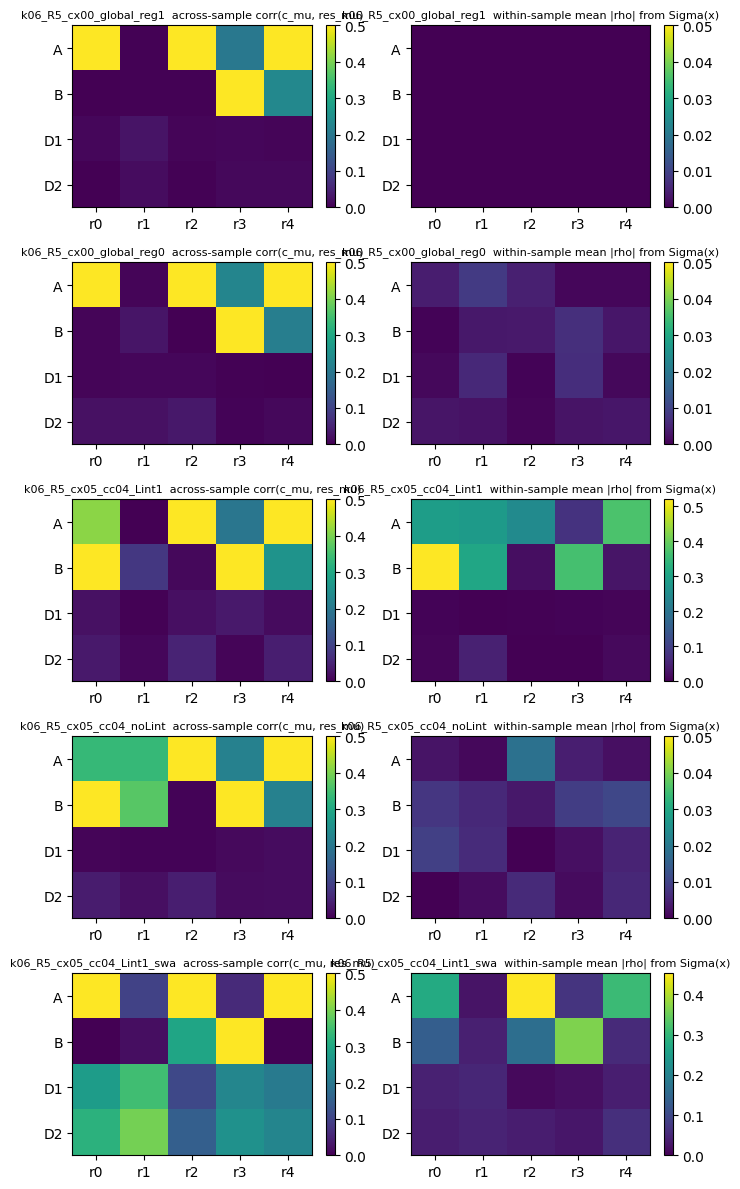

In [ ]:
n = len(LOADED)
if n:
    fig, axes = plt.subplots(n, 2, figsize=(7, 2.4 * n), squeeze=False)
    for r, (label, L) in enumerate(LOADED.items()):
        d = L["test"]
        for c, (M, title) in enumerate([(L["corr_mu"], "across-sample corr(c_mu, res_mu)"),
                                        (L["sigma_abs"], "within-sample mean |rho| from Sigma(x)")]):
            ax = axes[r, c]
            vmax = 0.5 if c == 0 else max(0.05, np.nanmax(M))
            im = ax.imshow(M if c else np.abs(M), cmap="viridis", vmin=0, vmax=vmax, aspect="auto")
            ax.set_yticks(range(d["C"])); ax.set_yticklabels(CONCEPTS[:d["C"]])
            ax.set_xticks(range(d["R"])); ax.set_xticklabels([f"r{j}" for j in range(d["R"])])
            ax.set_title(f"{label[:26]}  {title}", fontsize=8)
            plt.colorbar(im, ax=ax, fraction=0.05)
    plt.tight_layout(); plt.show()

### 3.6b The global Σ itself

Under `cov_type=global` every saved per-sample matrix is the same learned Σ, so it can be
drawn in full rather than averaged. Left: Σ with the diagonal, which is what the model
parameterises (the Cholesky factor's softplus diagonal starts at 0.48). Right: the
correlation matrix `Sigma_ij / sqrt(Sigma_ii Sigma_jj)` with the diagonal masked, on a
symmetric scale, so that off-diagonal structure is visible even when the variances dominate.
The concept-residual cross-block is the top-right 4 x R rectangle.


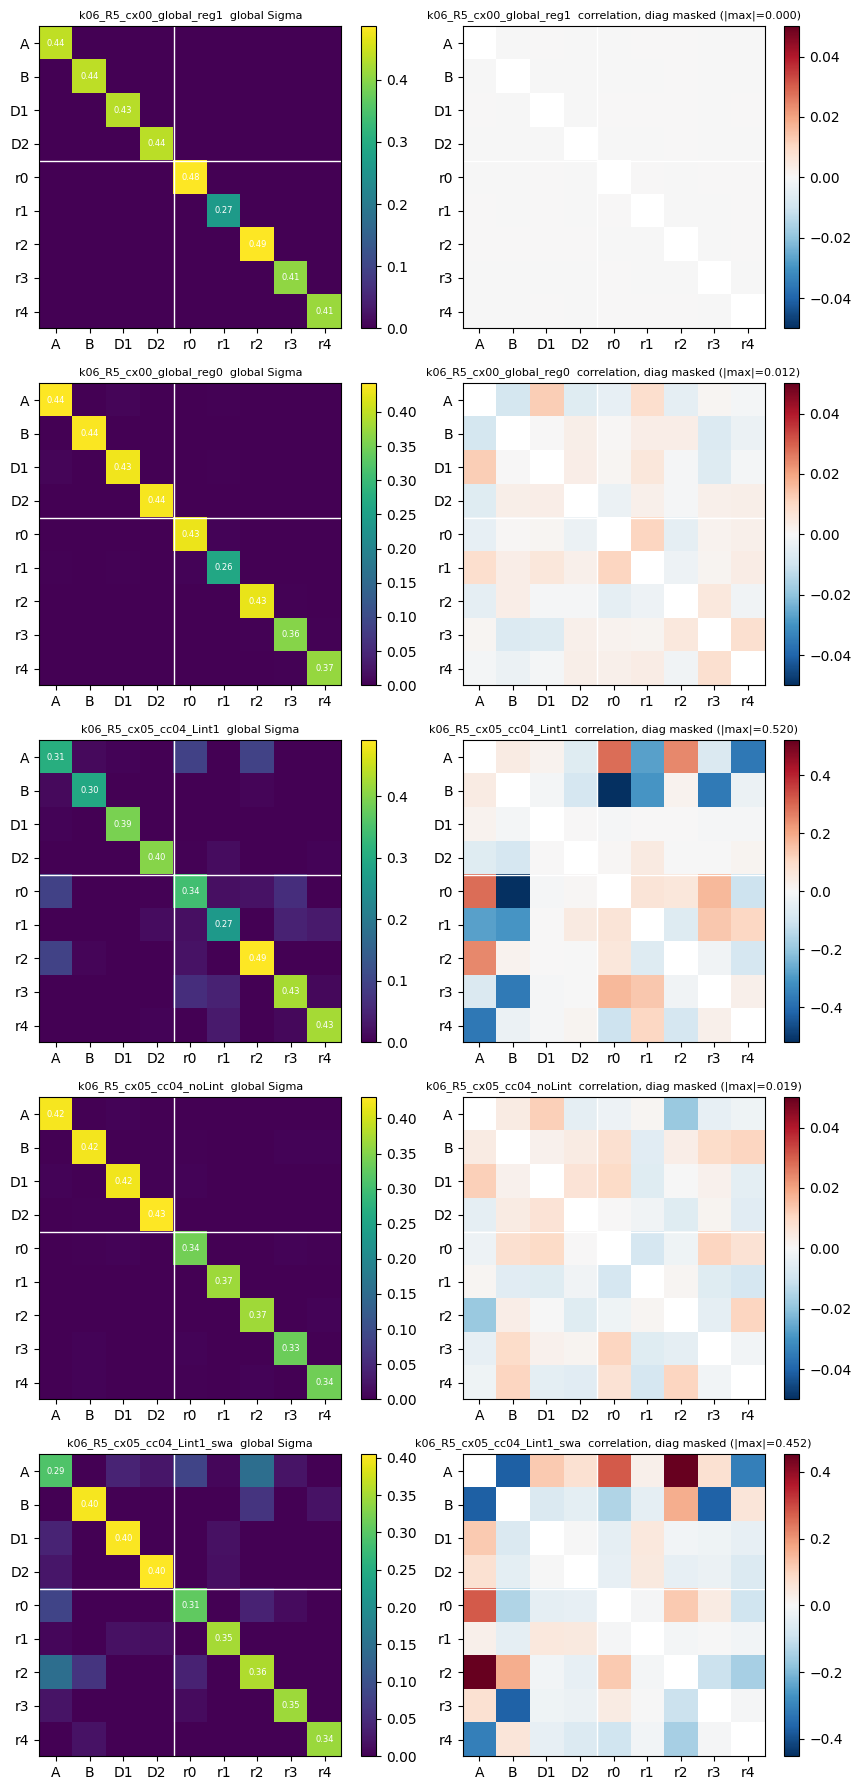

In [ ]:
gl = {lab: L for lab, L in LOADED.items() if L["cfg"]["model"]["cov_type"] == "global"}
if gl:
    fig, axes = plt.subplots(len(gl), 2, figsize=(9, 3.6 * len(gl)), squeeze=False)
    for r, (label, L) in enumerate(gl.items()):
        S = L["test"]["sigma"]; C, R = L["test"]["C"], L["test"]["R"]
        assert np.abs(S - S[0]).max() == 0, f"{label}: per-sample Sigma differ; not a global covariance"
        S = S[0]; names = CONCEPTS[:C] + [f"r{j}" for j in range(R)]
        sd = np.sqrt(np.diag(S)); rho = S / np.outer(sd, sd); np.fill_diagonal(rho, np.nan)
        lim = max(0.05, np.nanmax(np.abs(rho)))
        for c, (M, title, kw) in enumerate([
                (S,   "global Sigma",                         dict(cmap="viridis", vmin=0, vmax=S.max())),
                (rho, f"correlation, diag masked (|max|={np.nanmax(np.abs(rho)):.3f})", dict(cmap="RdBu_r", vmin=-lim, vmax=lim))]):
            ax = axes[r, c]; im = ax.imshow(M, aspect="equal", **kw)
            ax.set_xticks(range(C + R)); ax.set_xticklabels(names); ax.set_yticks(range(C + R)); ax.set_yticklabels(names)
            ax.axhline(C - 0.5, color="w", lw=1); ax.axvline(C - 0.5, color="w", lw=1)
            ax.set_title(f"{label[:26]}  {title}", fontsize=8); plt.colorbar(im, ax=ax, fraction=0.046)
            if c == 0:
                for i in range(C + R): ax.text(i, i, f"{S[i, i]:.2f}", ha="center", va="center", fontsize=6, color="w")
    plt.tight_layout(); plt.show()
else:
    print("no global-covariance run loaded")


### 3.6c Per-dimension correlation with the hidden variable

`corr(mu_rj(x), X)` for each residual dimension, on test, next to the same correlation after
`mu_rj` is OLS-residualised on `c_mu` (the partial correlation given the concepts). X is the
oracle here, so this is a check, not a method: it says which dimensions carry X at all and
whether they carry it *beyond* the concepts. The gap between the two bars on a dimension is
the part of its X-correlation that is inherited from a concept (a copy of A correlates with
X at corr(A, X) = kappa/2 and drops to zero once A is removed). The third panel is the same
correlation with each concept, for reference against the planted kappa/2.


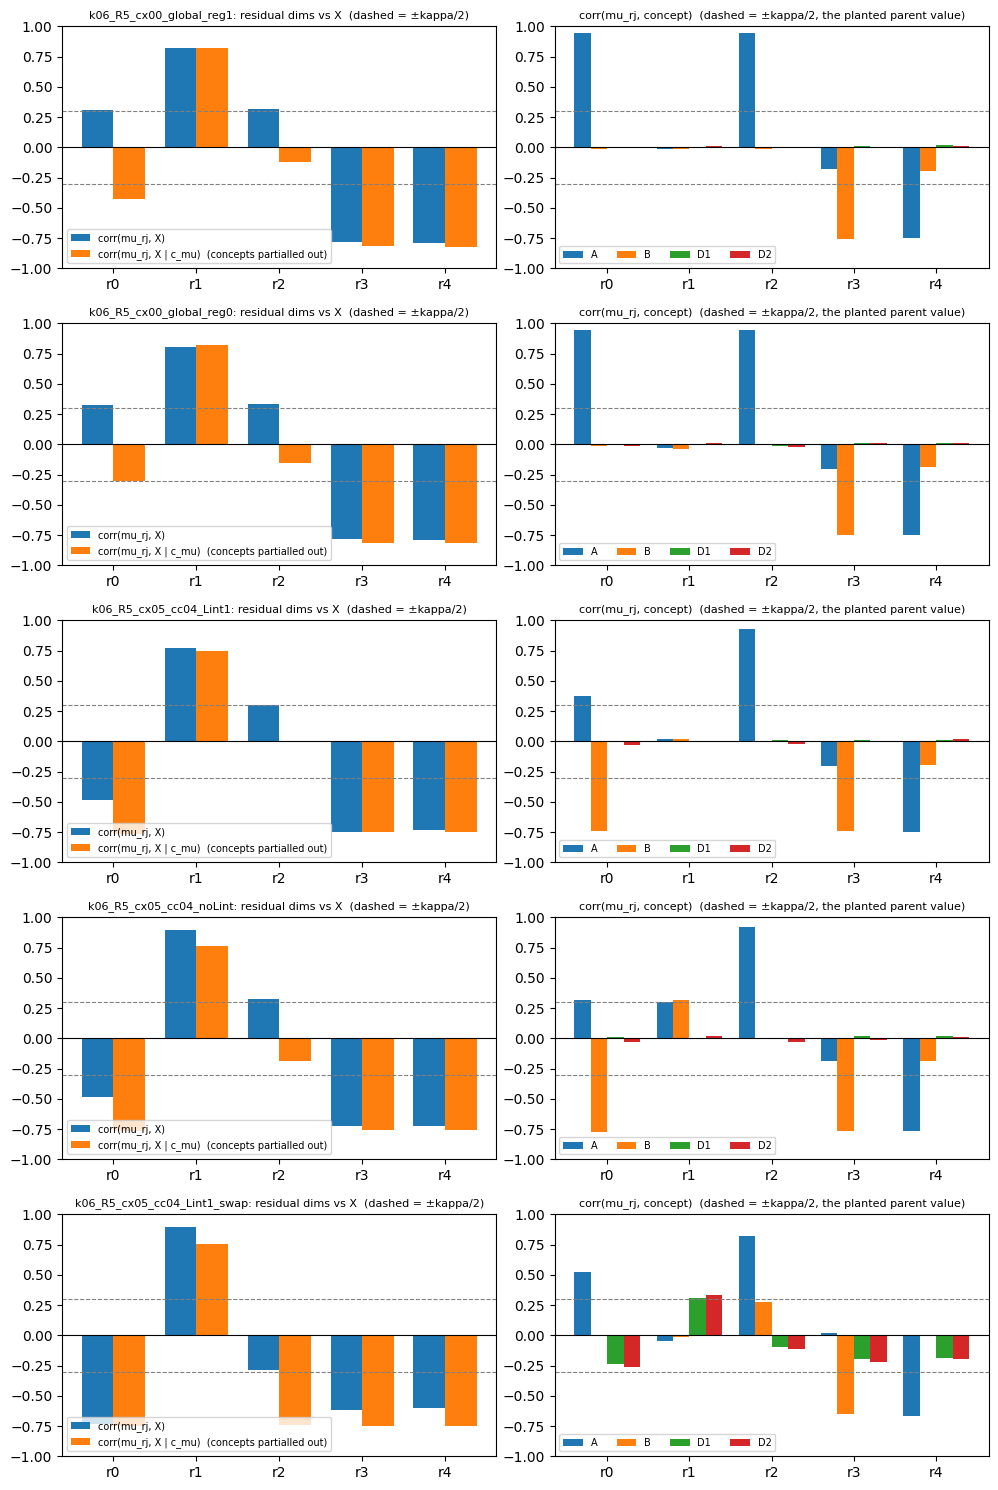

In [ ]:
n = len(LOADED)
if n:
    fig, axes = plt.subplots(n, 2, figsize=(10, 3.0 * n), squeeze=False)
    for r, (label, L) in enumerate(LOADED.items()):
        d = L["test"]; C, R = d["C"], d["R"]; k = L["kappa"]
        res, X = d["res_mu"], d["X"]; cleaned = ols_clean(res, d["c_mu"])
        raw  = np.array([np.corrcoef(res[:, j], X)[0, 1] for j in range(R)])
        part = np.array([np.corrcoef(cleaned[:, j], X)[0, 1] for j in range(R)])
        xs = np.arange(R); w = 0.38
        ax = axes[r, 0]
        ax.bar(xs - w/2, raw,  w, label="corr(mu_rj, X)")
        ax.bar(xs + w/2, part, w, label="corr(mu_rj, X | c_mu)  (concepts partialled out)")
        ax.axhline(0, color="k", lw=0.8); ax.axhline(k/2, color="grey", ls="--", lw=0.8)
        ax.axhline(-k/2, color="grey", ls="--", lw=0.8)
        ax.set_xticks(xs); ax.set_xticklabels([f"r{j}" for j in range(R)]); ax.set_ylim(-1, 1)
        ax.set_title(f"{label[:30]}: residual dims vs X  (dashed = ±kappa/2)", fontsize=8); ax.legend(fontsize=7, loc="lower left")
        # right: signed corr of each dim with each concept (true bits), grouped by dim
        ax = axes[r, 1]; cw = 0.8 / C
        for i in range(C):
            v = [np.corrcoef(res[:, j], d["c_true"][:, i])[0, 1] for j in range(R)]
            ax.bar(xs - 0.4 + cw * (i + 0.5), v, cw, label=CONCEPTS[i])
        ax.axhline(0, color="k", lw=0.8); ax.axhline(k/2, color="grey", ls="--", lw=0.8); ax.axhline(-k/2, color="grey", ls="--", lw=0.8)
        ax.set_xticks(xs); ax.set_xticklabels([f"r{j}" for j in range(R)]); ax.set_ylim(-1, 1)
        ax.set_title("corr(mu_rj, concept)  (dashed = ±kappa/2, the planted parent value)", fontsize=8); ax.legend(fontsize=7, ncol=4, loc="lower left")
    plt.tight_layout(); plt.show()


### 3.7 Dose-response across runs

With runs at several kappa, the parent correlation should rise linearly with kappa/2 while
the null concepts stay flat. This is the figure that turns the ratio into a measurement.

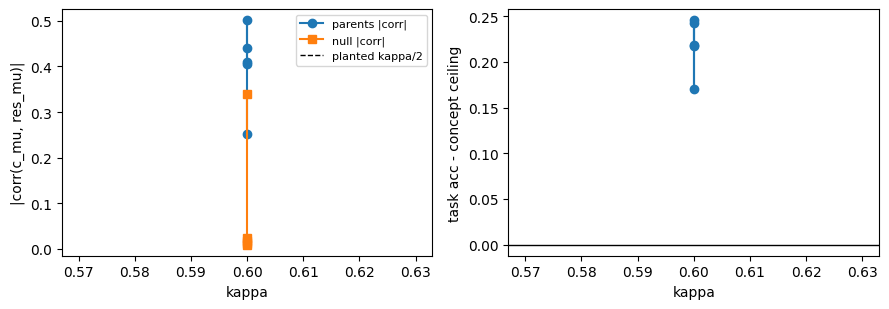

In [ ]:
if LOADED:
    ks = np.array([L["kappa"] for L in LOADED.values()])
    order = np.argsort(ks)
    labels = np.array(list(LOADED.keys()))[order]
    par = [np.abs(LOADED[l]["corr_mu"])[parents_of(LOADED[l]["cfg"]["data"]["experiment"])[0]].mean() for l in labels]
    nul = [np.abs(LOADED[l]["corr_mu"])[parents_of(LOADED[l]["cfg"]["data"]["experiment"])[1]].mean() for l in labels]
    acc = [LOADED[l]["acc"] - LOADED[l]["ceiling"] for l in labels]
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
    ax[0].plot(ks[order], par, "o-", label="parents |corr|"); ax[0].plot(ks[order], nul, "s-", label="null |corr|")
    ax[0].plot(ks[order], ks[order] / 2, "k--", lw=1, label="planted kappa/2")
    ax[0].set_xlabel("kappa"); ax[0].set_ylabel("|corr(c_mu, res_mu)|"); ax[0].legend(fontsize=8)
    ax[1].plot(ks[order], acc, "o-"); ax[1].axhline(0, color="k", lw=1)
    ax[1].set_xlabel("kappa"); ax[1].set_ylabel("task acc - concept ceiling")
    plt.tight_layout(); plt.show()

### 3.8 Per-cell accuracy: where does the model get X from?

`y = 4A + 2B + X`, so the predicted X bit is `argmax(y_pred) % 2`. Splitting by the four
(A, B) cells separates the two ways of being right about X: reading it off the concepts (the
cells where P(X=1) is far from 0.5) and reading it off channel 5 through the residual (the
A ≠ B cells, where the concepts give a coin flip). A model that never touched the residual
matches the "best guess from concepts" column in every cell and sits at 0.5 on the A ≠ B
cells. The task accuracy per cell is lower than the X-bit accuracy by the concept errors.

In [ ]:
for label, L in LOADED.items():
    d = L["test"]; A, B, X = d["c_true"][:, 0], d["c_true"][:, 1], d["X"]
    pred = d["y_pred"].argmax(1); pred_X = pred % 2
    print(f"\n{label}  (kappa={L['kappa']})")
    print(f"{'cell':<10} {'n':>5} {'P(X=1)':>7} {'concept guess':>13} {'y acc':>7} {'X-bit acc':>10}")
    for a in (0, 1):
        for b in (0, 1):
            mk = (A == a) & (B == b); p1 = X[mk].mean()
            print(f"A={a} B={b}   {mk.sum():>5} {p1:>7.3f} {max(p1, 1 - p1):>13.3f} "
                  f"{(pred[mk] == d['y_true'][mk]).mean():>7.3f} {(pred_X[mk] == X[mk]).mean():>10.3f}")
    coin = A != B
    print(f"X-bit accuracy on the A != B cells: {(pred_X[coin] == X[coin]).mean():.3f}   (0.5 = residual unused)")


k06_R5_cx00_global_reg1  (kappa=0.6)
cell           n  P(X=1) concept guess   y acc  X-bit acc
A=0 B=0    2500   0.197         0.803   0.792      0.991
A=0 B=1    2500   0.495         0.505   0.962      0.985
A=1 B=0    2500   0.496         0.504   0.962      0.990
A=1 B=1    2500   0.801         0.801   0.783      0.812
X-bit accuracy on the A != B cells: 0.988   (0.5 = residual unused)

k06_R5_cx00_global_reg0  (kappa=0.6)
cell           n  P(X=1) concept guess   y acc  X-bit acc
A=0 B=0    2500   0.197         0.803   0.787      0.991
A=0 B=1    2500   0.495         0.505   0.960      0.986
A=1 B=0    2500   0.496         0.504   0.963      0.990
A=1 B=1    2500   0.801         0.801   0.789      0.809
X-bit accuracy on the A != B cells: 0.988   (0.5 = residual unused)

k06_R5_cx05_cc04_Lint1  (kappa=0.6)
cell           n  P(X=1) concept guess   y acc  X-bit acc
A=0 B=0    2500   0.197         0.803   0.917      0.962
A=0 B=1    2500   0.495         0.505   0.906      0.946
A=1 B=0

### 3.8b Readouts split by mask status (`mask` corruption only)

The masking design says exactly where each mechanism has to work, so the readouts are
split by which channels were blanked. The mask is rebuilt from the run's own data config
and aligned to the dumps through `img_code.pt`, so nothing extra has to be saved.

- **X visible**: channel 5 carries X; the residual should read it near the backbone's
  channel-5 accuracy, and Σ is irrelevant.
- **X masked, parents visible**: X is unreadable; the best the model can do is the
  concept prior P(X | A, B), which lives in the *mean* (X-bit accuracy at the concept guess).
- **X masked and a parent masked**: the model is uncertain about X and about that parent at
  once, and they are correlated. This is the only group where a diagonal Σ is wrong, and the
  group the cross-block is learned from. Its size is `corruption_strength * concept_corruption_strength`.

The last table checks that masking actually creates concept-side uncertainty: the mean
|c_mu| of a concept on samples where its channel is blank should sit near zero (the logit
has nothing to go on), against the saturated values on visible samples. If it does not,
the model has learned a confident default for blank channels and Σ has no work to do there.


In [ ]:
from datasets.MNIST_add_cov_dataset_planted import get_MNIST_add_cov_datasets

def test_channel_mask(L):
    """[N, 5] bool mask for the run's test dumps, or None if the run has no mask corruption."""
    cd = L["cfg"]["data"]
    if "mask" not in {str(cd.get("corruption")), str(cd.get("concept_corruption"))}:
        return None
    cfg_d = OmegaConf.create(dict(cd)); OmegaConf.set_struct(cfg_d, False)
    cfg_d.data_path = DATA_PATH
    seed = cd.get("data_seed") if cd.get("data_seed") is not None else L["cfg"]["seed"]
    _, _, te = get_MNIST_add_cov_datasets(cfg_d, seed=seed)
    img_code = torch.load(L["dir"] / "test" / "img_code.pt", map_location="cpu").numpy()
    assert len(img_code) == len(te), "test dump and rebuilt test split differ in size"
    return np.stack([te[int(i)]["channel_mask"].numpy() for i in img_code])

for label, L in LOADED.items():
    M = test_channel_mask(L)
    if M is None:
        print(f"{label}: no mask corruption, skipped"); continue
    d = L["test"]; L["mask"] = M
    A, B, X = d["c_true"][:, 0], d["c_true"][:, 1], d["X"]
    pred = d["y_pred"].argmax(1); pred_X = pred % 2
    # concept guess for X: majority X per (A, B) cell, from the test labels themselves
    guess = np.zeros_like(X)
    for a in (0, 1):
        for b in (0, 1):
            mk = (A == a) & (B == b); guess[mk] = int(X[mk].mean() > 0.5)
    xm, am, bm = M[:, 4], M[:, 0], M[:, 1]
    groups = {
        "X visible":                       ~xm,
        "X masked, A and B visible":       xm & ~am & ~bm,
        "X masked, A masked (B visible)":  xm & am & ~bm,
        "X masked, B masked (A visible)":  xm & bm & ~am,
        "X masked, A and B masked":        xm & am & bm,
    }
    print(f"\n{label}  masked fractions per channel: {np.round(M.mean(0), 3).tolist()}")
    print(f"  {'group':<34} {'n':>5} {'y acc':>6} {'X-bit':>6} {'concept guess':>13} {'res probe AUC':>13}")
    for name, g in groups.items():
        if g.sum() < 50:
            print(f"  {name:<34} {g.sum():>5}   (too few)"); continue
        auc = cv_auc(d["res_mu"][g], X[g]) if len(np.unique(X[g])) == 2 else float("nan")
        print(f"  {name:<34} {g.sum():>5} {(pred[g] == d['y_true'][g]).mean():>6.3f} {(pred_X[g] == X[g]).mean():>6.3f} "
              f"{(guess[g] == X[g]).mean():>13.3f} {auc:>13.3f}")
    print(f"  {'concept':<8} {'|c_mu| visible':>15} {'|c_mu| masked':>14} {'acc visible':>12} {'acc masked':>11}")
    for i, cname in enumerate(CONCEPTS[:d["C"]]):
        mi = M[:, i]; cm = np.abs(d["c_mu"][:, i]); hit = (d["probs"][:, i] > 0.5) == (d["c_true"][:, i] > 0.5)
        print(f"  {cname:<8} {cm[~mi].mean():>15.2f} {cm[mi].mean() if mi.any() else float('nan'):>14.2f} "
              f"{hit[~mi].mean():>12.3f} {hit[mi].mean() if mi.any() else float('nan'):>11.3f}")


k06_R5_cx00_global_reg1: no mask corruption, skipped
k06_R5_cx00_global_reg0: no mask corruption, skipped
k06_R5_cx05_cc04_Lint1: no mask corruption, skipped
k06_R5_cx05_cc04_noLint: no mask corruption, skipped
k06_R5_cx05_cc04_Lint1_swap: no mask corruption, skipped


### 3.9 What the residual bit agrees with

The residual's thresholded probability is a bit. Its agreement rate with X, with each
concept and with each concept's complement says in one line whether it is carrying the
hidden variable or a *copy of an observed concept*. The complement is included because the
head can absorb either sign. Also reported: how saturated the residual probability is, and
the partial correlation of `res_mu` with X once the concepts are regressed out, which is
the number that survives for a residual that carries X and goes to zero for a copy.

The second table repeats the agreement with X inside each (A, B) cell, sign-free. A linear
head indexes its classes by (A, B, X) jointly, so a residual that equals X in some cells and
1 − X in others is exactly as useful to it as one that equals X everywhere. Pooled agreement
near 0.5 with high per-cell agreement and mixed signs therefore means "X re-coded by the
concepts", which is a different object from X for the covariance readout.

In [ ]:
print(f"{'run':<28} {'r=X':>6} {'r=A':>6} {'r=1-A':>6} {'r=B':>6} {'r=1-B':>6} {'r=D1':>6} {'r=D2':>6} | {'saturated':>9} {'pcorr(r,X|c)':>13}")
for label, L in LOADED.items():
    d = L["test"]; C = d["C"]
    for j in range(d["R"]):
        pr = d["probs"][:, C + j]; bit = pr > 0.5
        agree = lambda t: np.mean(bit == (t > 0.5))
        c = d["c_true"]
        sat = np.mean(np.abs(pr - 0.5) > 0.45)
        pc = np.corrcoef(ols_clean(d["res_mu"], d["c_mu"])[:, j], d["X"])[0, 1]
        print(f"{(label if j == 0 else ''):<28} {agree(d['X']):>6.3f} {agree(c[:,0]):>6.3f} {agree(1-c[:,0]):>6.3f} "
              f"{agree(c[:,1]):>6.3f} {agree(1-c[:,1]):>6.3f} {agree(c[:,2]):>6.3f} {agree(c[:,3]):>6.3f} | "
              f"{sat:>9.3f} {pc:>+13.3f}   res{j}")
print("\nAgreement near 0.5 everywhere = noise; near 1 on X = the residual carries X; near 1 on A or 1-A = a concept copy.")

# Per-cell agreement with X. A linear head indexes classes by (A, B, X) jointly, so it can
# decode a residual that equals X in some (A, B) cells and 1 - X in others just as well as
# one that equals X everywhere. Pooled agreement then sits near 0.5 while the residual is
# fully informative. max(agree, 1 - agree) inside each cell is the sign-free readout; if the
# four cells disagree on the sign, the residual is X re-coded by the concepts, not X.
print(f"\n{'run':<28} {'A0B0':>7} {'A0B1':>7} {'A1B0':>7} {'A1B1':>7}   per-cell |agreement(r, X)| and sign")
for label, L in LOADED.items():
    d = L["test"]; C = d["C"]; A, B, X = d["c_true"][:, 0], d["c_true"][:, 1], d["X"]
    for j in range(d["R"]):
        bit = d["probs"][:, C + j] > 0.5; cells = []
        for a in (0, 1):
            for b in (0, 1):
                mk = (A == a) & (B == b); ag = np.mean(bit[mk] == (X[mk] > 0.5))
                cells.append(f"{max(ag, 1-ag):.3f}{'+' if ag >= 0.5 else '-'}")
        print(f"{(label if j == 0 else ''):<28} " + " ".join(f"{s:>7}" for s in cells) + f"   res{j}")

run                             r=X    r=A  r=1-A    r=B  r=1-B   r=D1   r=D2 | saturated  pcorr(r,X|c)
k06_R5_cx00_global_reg1       0.651  0.985  0.015  0.501  0.499  0.499  0.490 |     0.989        -0.430   res0
                              0.780  0.449  0.551  0.444  0.556  0.502  0.504 |     0.975        +0.818   res1
                              0.651  0.985  0.015  0.502  0.498  0.499  0.490 |     0.989        -0.123   res2
                              0.178  0.426  0.574  0.178  0.822  0.507  0.500 |     0.990        -0.820   res3
                              0.176  0.179  0.821  0.426  0.574  0.503  0.511 |     0.991        -0.821   res4
k06_R5_cx00_global_reg0       0.652  0.988  0.012  0.502  0.498  0.498  0.491 |     0.989        -0.303   res0
                              0.782  0.449  0.551  0.446  0.554  0.501  0.503 |     0.970        +0.818   res1
                              0.653  0.988  0.012  0.503  0.497  0.498  0.490 |     0.990        -0.151   res2
        

### 3.10 Head weights: what the head does with the residual

For a linear head, `head.0.weight` is `[8 classes × (A, B, D1, D2, r…)]`. Class k has bits
(A, B, X) = (k>>2, (k>>1)&1, k&1). A head that reads X from the residual has the residual
column positive on the odd classes (X = 1) and negative on the even ones, with the same
pattern in every (A, B) block. A head that uses the residual as a second vote on A has the
residual column following the A pattern instead: one sign on classes 0-3, the other on 4-7.

In [ ]:
for label, L in LOADED.items():
    sd = torch.load(L["dir"] / "model_best.pth", map_location="cpu")
    keys = [k for k in sd if k.startswith("head.") and k.endswith("weight")]
    if len(keys) != 1:
        print(f"{label}: non-linear head ({len(keys)} weight matrices), skipping"); continue
    W = sd[keys[0]].float().numpy(); C = L["test"]["C"]; R = L["test"]["R"]
    names = CONCEPTS[:C] + [f"r{j}" for j in range(R)]
    print(f"\n{label}")
    print(f"{'class':<6} {'(A,B,X)':<9} " + " ".join(f"{n:>7}" for n in names))
    for k in range(W.shape[0]):
        bits = (k >> 2, (k >> 1) & 1, k & 1)
        print(f"{k:<6} {str(bits):<9} " + " ".join(f"{w:>+7.2f}" for w in W[k]))
    # Which pattern does each residual column follow? Correlate it with the class bit patterns.
    kk = np.arange(W.shape[0]); patt = {"A": kk >> 2, "B": (kk >> 1) & 1, "X": kk & 1}
    for j in range(R):
        col = W[:, C + j]
        print(f"  r{j} column follows: " + "  ".join(f"{n}={np.corrcoef(col, p)[0,1]:+.2f}" for n, p in patt.items()))


k06_R5_cx00_global_reg1
class  (A,B,X)         A       B      D1      D2      r0      r1      r2      r3      r4
0      (0, 0, 0)   -0.68   -0.62   -0.16   +0.16   -0.75   +0.62   -0.89   +0.96   +0.89
1      (0, 0, 1)   -0.40   -0.36   -0.10   -0.07   -0.61   +0.49   -0.73   -0.78   -0.75
2      (0, 1, 0)   -0.42   +0.49   +0.03   +0.30   -0.89   -0.90   -0.33   -0.83   +0.91
3      (0, 1, 1)   -0.57   +0.47   +0.12   +0.14   -0.97   +0.49   -0.89   -0.73   -1.02
4      (1, 0, 0)   +0.16   -0.67   -0.18   +0.09   +0.64   -0.94   +0.56   +0.71   -0.86
5      (1, 0, 1)   +0.21   -0.89   -0.13   -0.09   +0.32   +0.30   +0.71   -0.87   -0.75
6      (1, 1, 0)   +0.13   +0.24   -0.34   -0.19   +0.37   -0.87   +0.33   -0.58   -0.81
7      (1, 1, 1)   +0.61   +0.78   -0.29   -0.10   +0.35   +0.57   +0.61   -0.48   -0.43
  r0 column follows: A=+0.98  B=-0.15  X=-0.06
  r1 column follows: A=-0.30  B=-0.21  X=+0.72
  r2 column follows: A=+0.96  B=+0.01  X=+0.01
  r3 column follows: A=+0.03  B=-

### 3.11 Concept signature of what the residual encodes

Section 3.4 asks "which concepts does the residual co-vary with?" and, on the R = 5 runs,
answers "A" with a correlation of 1.0. That is the wrong object: a residual dimension that
*copies* A co-varies with A perfectly and encodes nothing new. The planted question is about
the hidden variable, which co-varies with its parents at only kappa/2. The two have to be
separated before the concept connections mean anything.

Three steps, all covariance-free and all on the test dumps:

1. **Copy fraction per dimension**: R² of `res_j` on `[1, c_mu]`. A copy is ~1, a novel
   variable is at most corr² with its parents (0.09 + 0.09 here).
2. **Sufficiency per dimension**: 5-fold CV task accuracy from `c_mu` alone versus
   `c_mu + res_j`. A copy adds nothing; the X carrier adds up to the residual headroom.
   Together, 1 and 2 label every dimension as copy / novel / mixed / unused, where *mixed* is
   a dimension that adds task accuracy but is largely explained by the concepts: the hidden
   variable re-coded by a concept (X xor A, say), which a linear head can still decode.
3. **Hidden direction and its concept signature**: fit the task on `[c_mu, cleaned res]`,
   where the residual is OLS-residualised on `c_mu` so copies carry no weight, and take the
   leading direction `u` of the residual weight block. Then project the *raw* residual on
   `u` and correlate with each concept. Fitting on cleaned data picks the direction that is
   new; correlating the raw projection keeps the shared variance that cleaning would remove.
   The row of correlations is the concept signature of the hidden variable: on
   `planted_parents` it should read ≈ +kappa/2 on A and B and ≈ 0 on D1 and D2.

The oracle column (corr with X) is only there to check the direction; nothing in steps 1-3
uses X. Sign: `u` is oriented so that the projection correlates positively with y.


In [ ]:
from sklearn.model_selection import cross_val_score

def zs(Z): return (Z - Z.mean(0)) / (Z.std(0) + 1e-8)

def r2_on_concepts(res, c):
    Xd = np.column_stack([np.ones(len(c)), c])
    beta, *_ = np.linalg.lstsq(Xd, res, rcond=None)
    ss_res = ((res - Xd @ beta) ** 2).sum(0); ss_tot = ((res - res.mean(0)) ** 2).sum(0)
    return 1 - ss_res / ss_tot

def cv_task_acc(Z, y, seed=0):
    clf = LogisticRegression(max_iter=3000, C=1.0)
    return cross_val_score(clf, zs(Z), y, cv=StratifiedKFold(5, shuffle=True, random_state=seed)).mean()

for label, L in LOADED.items():
    d = L["test"]; C, R = d["C"], d["R"]; k = L["kappa"]
    c_mu, res, y, X = d["c_mu"], d["res_mu"], d["y_true"], d["X"]
    names_c = CONCEPTS[:C]

    # 1 + 2: per-dimension copy fraction and sufficiency
    copy_r2 = r2_on_concepts(res, c_mu)
    base = cv_task_acc(c_mu, y)
    print(f"\n{label}  (kappa={k}, planted parent corr={k/2:+.2f})")
    print(f"  task acc from c_mu alone: {base:.4f}   (ceiling {L['ceiling']:.4f}, full model {L['acc']:.4f})")
    print(f"  {'dim':<5} {'copy R2':>8} {'+acc':>7} {'verdict':<8} " + " ".join(f"{'corr '+n:>8}" for n in names_c))
    for j in range(R):
        gain = cv_task_acc(np.column_stack([c_mu, res[:, j]]), y) - base
        # copy: explained by the concepts and adds nothing. novel: adds task accuracy and is
        # not explained by them. mixed: adds accuracy *and* is largely explained -- the
        # hidden variable re-coded by a concept (e.g. X xor A), which the head can still use.
        if gain <= 0.05:   verdict = "copy" if copy_r2[j] > 0.5 else "unused"   # 0.05: above 5-fold CV noise on 10k samples
        else:              verdict = "novel" if copy_r2[j] < 0.3 else "mixed"
        cc = [np.corrcoef(res[:, j], d["c_true"][:, i])[0, 1] for i in range(C)]
        print(f"  r{j:<4} {copy_r2[j]:>8.3f} {gain:>+7.3f} {verdict:<8} " + " ".join(f"{v:>+8.3f}" for v in cc))

    # 3: hidden direction from the cleaned residual, signature from the raw projection
    cleaned = ols_clean(res, c_mu)
    Z = zs(np.column_stack([c_mu, cleaned]))
    clf = LogisticRegression(max_iter=3000, C=1.0).fit(Z, y)
    W_r = clf.coef_[:, C:]                                          # [K, R]
    u = np.linalg.svd(W_r, full_matrices=False)[2][0]
    proj = zs(res) @ u
    if np.corrcoef(proj, y)[0, 1] < 0: u, proj = -u, -proj
    sig_true = np.array([np.corrcoef(proj, d["c_true"][:, i])[0, 1] for i in range(C)])
    sig_mu   = np.array([np.corrcoef(proj, c_mu[:, i])[0, 1] for i in range(C)])
    L.update(dict(u=u, signature=sig_true))
    print(f"  hidden direction u = " + " ".join(f"r{j}:{w:+.2f}" for j, w in enumerate(u))
          + f"   copy R2 of proj: {r2_on_concepts(proj[:, None], c_mu)[0]:.3f}   corr(proj, X) [oracle]: {np.corrcoef(proj, X)[0,1]:+.3f}")
    print(f"  concept signature (corr with c_true): " + "  ".join(f"{n}={v:+.3f}" for n, v in zip(names_c, sig_true)))
    print(f"  concept signature (corr with c_mu)  : " + "  ".join(f"{n}={v:+.3f}" for n, v in zip(names_c, sig_mu)))
    par, nul = parents_of(L["cfg"]["data"]["experiment"])
    print(f"  parents mean {np.abs(sig_true[par]).mean():+.3f} vs planted {k/2:+.3f};  null mean {np.abs(sig_true[nul]).mean():.3f}")



k06_R5_cx00_global_reg1  (kappa=0.6, planted parent corr=+0.30)
  task acc from c_mu alone: 0.7297   (ceiling 0.6568, full model 0.8748)
  dim    copy R2    +acc verdict    corr A   corr B  corr D1  corr D2


  r0       0.999  +0.031 copy       +0.944   -0.015   -0.000   -0.000
  r1       0.001  +0.237 novel      -0.011   -0.016   -0.000   +0.009


  r2       1.000  +0.004 copy       +0.944   -0.013   -0.001   +0.002
  r3       0.702  +0.237 mixed      -0.183   -0.757   +0.011   +0.002
  r4       0.690  +0.236 mixed      -0.748   -0.196   +0.018   +0.011


  hidden direction u = r0:-0.02 r1:+0.58 r2:-0.03 r3:-0.55 r4:-0.60   copy R2 of proj: 0.302   corr(proj, X) [oracle]: +0.940
  concept signature (corr with c_true): A=+0.343  B=+0.363  D1=-0.011  D2=-0.002
  concept signature (corr with c_mu)  : A=+0.375  B=+0.408  D1=+0.010  D2=-0.002
  parents mean +0.353 vs planted +0.300;  null mean 0.007

k06_R5_cx00_global_reg0  (kappa=0.6, planted parent corr=+0.30)
  task acc from c_mu alone: 0.7255   (ceiling 0.6568, full model 0.8749)
  dim    copy R2    +acc verdict    corr A   corr B  corr D1  corr D2


  r0       0.999  +0.016 copy       +0.943   -0.015   -0.009   -0.015
  r1       0.001  +0.242 novel      -0.030   -0.036   -0.004   +0.009


...

  r2       0.999  +0.009 copy       +0.922   +0.007   -0.003   -0.034
  r3       0.755  +0.237 mixed      -0.192   -0.764   +0.018   -0.013
  r4       0.754  +0.239 mixed      -0.768   -0.191   +0.019   +0.013


  hidden direction u = r0:-0.42 r1:+0.77 r2:-0.00 r3:-0.07 r4:-0.47   copy R2 of proj: 0.431   corr(proj, X) [oracle]: +0.878
  concept signature (corr with c_true): A=+0.323  B=+0.488  D1=-0.013  D2=+0.015
  concept signature (corr with c_mu)  : A=+0.363  B=+0.548  D1=-0.005  D2=+0.016
  parents mean +0.406 vs planted +0.300;  null mean 0.014

k06_R5_cx05_cc04_Lint1_swap  (kappa=0.6, planted parent corr=+0.30)
  task acc from c_mu alone: 0.6753   (ceiling 0.6584, full model 0.9010)
  dim    copy R2    +acc verdict    corr A   corr B  corr D1  corr D2


  r0       0.526  +0.234 mixed      +0.527   +0.001   -0.241   -0.263
  r1       0.284  +0.234 novel      -0.048   -0.018   +0.311   +0.332


  r2       0.943  +0.231 mixed      +0.822   +0.272   -0.094   -0.117
  r3       0.625  +0.233 mixed      +0.015   -0.648   -0.197   -0.217


  r4       0.604  +0.234 mixed      -0.667   +0.002   -0.186   -0.193
  hidden direction u = r0:+0.27 r1:-0.64 r2:+0.54 r3:-0.11 r4:+0.46   copy R2 of proj: 0.351   corr(proj, X) [oracle]: -0.850
  concept signature (corr with c_true): A=+0.231  B=+0.171  D1=-0.284  D2=-0.309
  concept signature (corr with c_mu)  : A=+0.294  B=+0.185  D1=-0.318  D2=-0.374
  parents mean +0.297 vs planted +0.300;  null mean 0.201


### Worked example: the cc04 / cx05 / extended-L_int run of 16 September

`planted_..._k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_15-16-51_seed_0_c84e5`
(matched backbone `planted_parents_k06_cx05_cc04_s0_perchannel`, R = 5, global Σ, reg 0,
weight decay 1e-4, **concept channels corrupted at 0.4**, X channel at 0.5, **extended L_int
at weight 1**). Compared against the two cc00 runs of the same day, on test:

- **3.2** y accuracy 0.903 against the 0.657 ceiling (+0.246, the best margin so far). The
  A ≠ B cells drop from 0.96 to 0.905 (channel 5 is noisier) but the A = B cells *rise*
  from 0.79 to 0.90, because L_int pushes the head to rely on the residual's X rather than
  on the concept majority guess.
- **3.3** Cleaned probe 0.953 (cc00: 0.978), ΔAUC +0.220. X is still in the residual beyond
  the concepts; the ~0.03 loss is the extra noise on channel 5.
- **3.8** X bit at 0.948 on the A ≠ B cells (cc00: 0.988). Residual is used.
- **3.11** Same dimension roles as cc00: r1 is the clean X carrier (copy R² 0.007, +0.222
  task accuracy), r2 is a pure copy of A (R² 1.000, +0.000), r3/r4 are X re-coded by B and A.
  The difference is r0: in cc00 it was a second copy of A, here it is a *mixed* dimension
  (R² 0.83, +0.222) correlated −0.74 with B. Because r0 is now task-relevant the hidden
  direction `u` loads on it (−0.79) and the concept signature is pulled off the planted
  value: A = −0.33, B = +0.63 instead of the +0.34 / +0.36 the cc00 runs give. Parent
  *magnitude* still beats null by 37×, so membership is right and sign is not.
- **3.4 / 3.6b (the new result)** With concept corruption on, the global Σ has a non-zero
  concept-residual cross-block for the first time: |rho| up to 0.52 between B and r0, 0.29-0.37
  between A and r0/r1/r4, and D1/D2 at ≤ 0.05 everywhere. On the cc00 runs every entry was
  ≤ 0.012. Σ is separating parents from distractors, as the design predicts. Two caveats:
  the largest entries sit on r0 (the mixed copy), not on r1 (the X carrier, where A and B are
  at 0.28 and 0.31), and the signs are mixed across the cross-block, so it identifies *which*
  concepts the residual is entangled with, not the sign or the value of corr(c, X).

### The control: same settings, no L_int (16 September, 16:21)

`planted_..._k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_noLint_2026-09-16_16-21-46_seed_0_a3e46`
is the L_int run with both L_int losses off (and early-stopping patience 10 rather than 30,
so it trained for ~35 epochs and lands at y accuracy 0.827 instead of 0.903). On test:

- **3.3 / 3.8** Residual content is unchanged: cleaned probe 0.950, ΔAUC +0.221, X bit
  0.943 on the A ≠ B cells. Concept corruption alone does not stop the residual learning X.
- **3.9 / 3.10 / 3.11** r1 is the cleanest X carrier of any run: it agrees with X on 0.956
  of samples with the *same sign in all four (A, B) cells*, its head column follows the X
  pattern at +0.94 and nothing else, and its across-sample correlation with the concepts is
  A = +0.30, B = +0.32, D1 = D2 = 0 — the planted kappa/2 read off a single dimension with no
  cleaning. The hidden-direction signature is A = +0.32, B = +0.49, null 0.01: right in sign,
  B still inflated by r0, the mixed dimension.
- **3.4 / 3.6b** The Σ cross-block is **gone**: every concept-residual |rho| ≤ 0.02, the same
  floor as the cc00 runs. Σ_ii sits at 0.42 on the concepts and 0.33-0.37 on the residuals,
  i.e. the initialisation scale, so Σ was never trained into anything.

Reading, with the confound resolved: **extended L_int is what switches on the Σ
cross-block; concept corruption is not.** Without L_int the covariance has no gradient
signal that depends on its off-diagonals (the task loss sees only sampled logits), so it
stays at initialisation. With L_int, training intervenes on concepts and propagates the
intervention through Σ_rc Σ_cc⁻¹ into the residual, so the cross-block is fitted to
whatever makes the *intervened* model predict y well: it moves the residual's A- and
B-copy dimensions along with A and B, and (see the intervention-gain projection in the
discussion of this run) leaves the X direction alone. The cross-block is therefore the
model's learned leakage map, which happens to sit on A and B because those are the only
concepts the residual copies. It is not a readout of X's parents, and the parents-vs-null
pattern cannot be credited to the planted dependence until `planted_swap` moves it to D1/D2.

### The decider: `planted_swap` at the same settings (16 September, 17:00)

`planted_planted_swap_planted_swap_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_17-00-03_seed_0_327de`
is the L_int run with X generated from D1/D2 instead of A/B (patience 10). y is still
4A + 2B + X, so the task concepts stay A and B while the planted parents move to D1 and D2.
The two readings of the cross-block now predict different concepts. On test:

- **3.2 / 3.3 / 3.8** Unchanged: y accuracy 0.901 vs a 0.658 ceiling, cleaned probe 0.947,
  X bit 0.96 in every (A, B) cell (all four are coin flips under swap, so the residual is the
  only source of X and the model uses it).
- **3.9 / 3.10** r1 is again the X carrier: agreement with X 0.96 with the same sign in all
  four cells, head column follows X at +0.97. r0, r2, r3, r4 are copies / re-codings of A and B
  exactly as before, i.e. the residual still copies the *task* concepts, not the parents.
- **Across-sample (3.4, 3.6c)** The X carrier's correlation with the concepts *moved with the
  planted dependence*: r1 vs D1 = +0.31, D2 = +0.33, A = −0.05, B = −0.02. That is kappa/2 on
  the new parents and zero on the old ones. Read per dimension, the across-sample statistic
  tracks the design. Read as the section-3.5 average over all five dimensions it does not
  (ratio 0.74), because four of the five dimensions are A/B copies and swamp the mean.
- **Σ (3.4 within-sample, 3.6b)** The cross-block **stayed on A and B**: |rho| 0.28-0.45 on the
  A row, 0.13-0.37 on the B row, ≤ 0.06 on D1 and D2. Mean |rho| on the task concepts 0.19,
  on the planted parents 0.04. The leading concept-side singular vector of the cross-block is
  (A, B, D1, D2) = (1.00, 0.00, −0.01, −0.03), i.e. pure A. The intervention-gain projection onto the
  residual's X direction is zero for all four concepts, as in the parents run.
- **3.11 signature** from the hidden direction: parents mean 0.30 = planted, but null mean
  0.20 (A/B leak in through the mixed dimensions), and the sign came out flipped because the
  direction is oriented by its correlation with y, which under swap is dominated by A and B.

Conclusion. **Σ's cross-block is the leakage map, not a readout of the planted dependence.**
Under L_int it couples the residual to whichever concepts the residual copies, and those are
the task concepts, so it sits on A and B regardless of where X comes from. The
parents-vs-null pattern in the `planted_parents` L_int run was a coincidence of A and B
being both the parents *and* the task concepts. The statistic that does follow the
dependence is the across-sample correlation of the identified X-carrying dimension (or the
cleaned hidden direction) with the concepts: kappa/2 on A, B under parents and on D1, D2
under swap, with the other pair at zero, in both cases without any oracle access to X.


### Worked example: the kappa 0.9 run of 8 September

`planted_planted_parents_planted_parents_kappa09_corr04_L_int_extension_loss_weight_1_2026-09-08_17-50-00_b226c`
(stacked encoder from scratch, global covariance, lr 1e-3, no weight decay, extended L_int at
weight 1, one residual) is the negative control that the cleaning step exists for. From the
sections above, on test:

- **3.2** y accuracy 0.627 against a concept-only ceiling of 0.732. Below the ceiling because
  each concept is read at only about 0.92, and all four together at 0.71.
- **3.8** On the A ≠ B cells the model's X bit is at 0.51 and 0.54: chance. It never read
  channel 5. In the A = B cells it matches the concept guess.
- **3.9** The residual bit equals 1 − A on 83 % of samples and X on 39 %, below chance. 89 %
  of residual probabilities are saturated. Partial correlation with X given the concepts: −0.01.
- **3.3** Raw probe on X 0.63, cleaned 0.51, ΔAUC over the concept-only probe 0.000.
- **3.4 / 3.5** Across-sample corr with A −0.93, with B +0.34, distractors near zero; the Σ(x)
  cross-block has A at 0.84 and the rest near 0.2; parent-to-null ratio 15.
- **3.10** The residual column of the head follows the A pattern, not the X pattern: the head
  uses the residual as a second vote on A.

Every identification statistic fires, and it is identifying a copied concept. The −0.22 raw
correlation with X is inherited entirely from A, since X is correlated with A by design.
With a learning rate of 1e-3, no weight decay, and concepts read at 0.92, routing A through
the free channel a second time was the fastest way to lower the target loss, and learning X
from a corrupted digit never won the race. The matched backbone (concepts at 0.99, so a second
vote on A is worthless), weight decay, no L_int, and kappa 0.6 are what changed in the
15 September run, whose train accuracy passed the ceiling at epoch 48.

The general rule this run gives: a large, well-structured concept-residual correlation is
not evidence of a hidden concept until the cleaned probe and the per-cell X-bit accuracy say
the residual carries something the concepts do not.

## What to conclude

In order; each step is only meaningful if the one before it passed.

1. **Backbone** (§2): channels 1-4 near 0.98, channel 5 well above 0.9. If channel 5 is
   poor, the corruption is too strong for the digit reader and the residual has nothing to
   work with.
2. **Settings** (§3.1): no precision penalty, no L_int, linear head, a learning covariance.
3. **Task accuracy above the ceiling** (§3.2): the only way to get there is the residual.
4. **The residual holds X** (§3.3, §3.8, §3.9): the cleaned probe clears the X ceiling, the X bit is
   above 0.5 on the A ≠ B cells, and the residual bit agrees with X rather than with a concept.
5. **The correlation points at the parents** (§3.4, §3.5): parent columns near kappa/2, null
   columns near the kappa = 0 floor. `planted_swap` must flip it.
6. **Σ(x)** (§3.4, within-sample) only once concept corruption is on; on clean concept
   channels the concept variances collapse and that panel is expected to be empty.

If 1-4 pass and 5 comes out flat, that is a real negative about the covariance as an
identification tool and worth reporting as one. If 3 fails, the residual was never trained
and 5 tells you nothing.